Environment ready!
NumPy: 2.3.4
pandas: 2.3.3
scikit-learn: 1.9.1

--- Available Columns ---
['StudentID', 'G1', 'G2', 'G3', 'Mjob', 'Fjob', 'age', 'address', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
-------------------------

--- Mean stats by passing status ---
        studytime        G1        G2
passed                               
No       2.203704  9.703704  9.388889
Yes      2.217391  8.195652  7.913043
------------------------------------



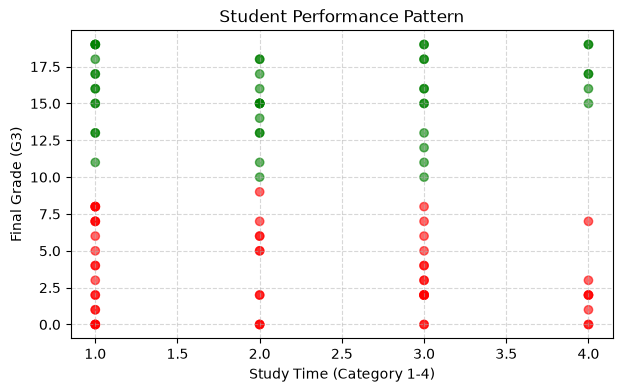

X shape: (100, 4)
y shape: (100,)
Training rows: 80
Testing rows : 20

Decision Tree with max_depth = 3
Model trained successfully!
Test Accuracy: 40.00%

Confusion Matrix:
[[4 7]
 [5 4]]

Classification Report:
              precision    recall  f1-score   support

          No       0.44      0.36      0.40        11
         Yes       0.36      0.44      0.40         9

    accuracy                           0.40        20
   macro avg       0.40      0.40      0.40        20
weighted avg       0.41      0.40      0.40        20


Decision Tree with max_depth = 4
Model trained successfully!
Test Accuracy: 40.00%

Confusion Matrix:
[[4 7]
 [5 4]]

Classification Report:
              precision    recall  f1-score   support

          No       0.44      0.36      0.40        11
         Yes       0.36      0.44      0.40         9

    accuracy                           0.40        20
   macro avg       0.40      0.40      0.40        20
weighted avg       0.41      0.40      0.40    

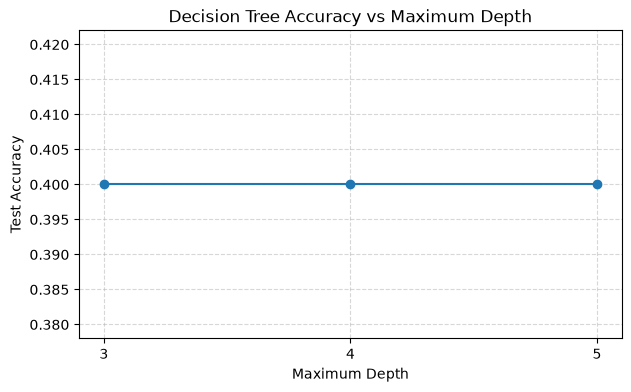

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)



df = pd.read_csv("student_performance.csv")

df.columns = df.columns.str.strip()

print("\n--- Available Columns ---")
print(df.columns.tolist())
print("-------------------------\n")



df["passed"] = np.where(df["G3"] >= 10, "Yes", "No")

print("--- Mean stats by passing status ---")

print(
    df.groupby("passed")[["studytime", "G1", "G2"]].mean()
)

print("------------------------------------\n")



plt.figure(figsize=(7, 4))

plt.scatter(
    df["studytime"],
    df["G3"],
    c=df["passed"].map({"Yes": "green", "No": "red"}),
    alpha=0.6
)

plt.xlabel("Study Time (Category 1-4)")
plt.ylabel("Final Grade (G3)")
plt.title("Student Performance Pattern")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()




X = df[["studytime", "age", "G1", "G2"]]

y = df["passed"]

print("X shape:", X.shape)
print("y shape:", y.shape)




X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))




depths = [3, 4, 5]

results = []

for depth in depths:

    print("\n===================================")
    print("Decision Tree with max_depth =", depth)
    print("===================================")

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    print("Model trained successfully!")


    y_pred = model.predict(X_test)

    
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Test Accuracy: {accuracy:.2%}")


    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    results.append({
        "Max Depth": depth,
        "Accuracy": accuracy
    })



results_df = pd.DataFrame(results)

print("\n\n========== COMPARISON ==========")

print(results_df)



plt.figure(figsize=(7, 4))

plt.plot(
    results_df["Max Depth"],
    results_df["Accuracy"],
    marker="o"
)

plt.xlabel("Maximum Depth")
plt.ylabel("Test Accuracy")
plt.title("Decision Tree Accuracy vs Maximum Depth")

plt.xticks([3, 4, 5])
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Environment ready!

--- Available Columns ---
['Temperature_C', 'Voltage_V', 'Current_A', 'Machine_Failure']
-------------------------

--- First 10 Rows ---
   Temperature_C  Voltage_V  Current_A Machine_Failure
0          46.73     221.24       1.56              No
1          61.93     238.52       2.77             Yes
2          54.92     231.96       2.13              No
3          56.90     227.96       2.52             Yes
4          67.42     214.68       3.32             Yes
5          52.16     214.68       2.00              No
6          52.59     211.74       2.32              No
7          64.69     235.99       3.01             Yes
8          50.92     228.03       1.96              No
9          50.84     231.24       1.65              No

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperat

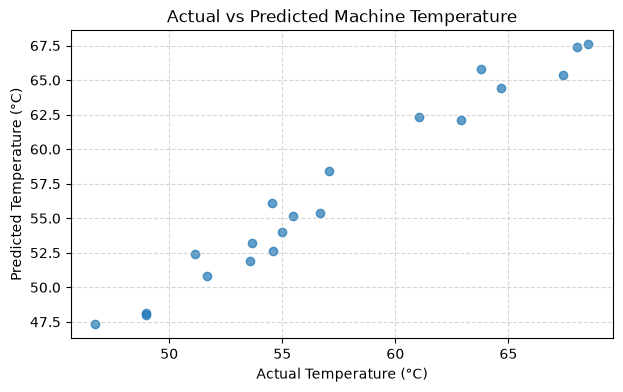

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Environment ready!")

# Load dataset
df = pd.read_csv("machine_temperature_data.csv")
df.columns = df.columns.str.strip()

print("\n--- Available Columns ---")
print(df.columns.tolist())
print("-------------------------")

print("\n--- First 10 Rows ---")
print(df.head(10))

print("\n--- Dataset Information ---")
print(df.info())

print("\n--- Statistical Summary ---")
print(df.describe())

# --------------------------------------------------
# STEP 1: Select Input and Target
# --------------------------------------------------

# Input features
X = df[["Voltage_V", "Current_A"]]

# Target: Machine Temperature
y = df["Temperature_C"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

# --------------------------------------------------
# STEP 2: Split Dataset
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining rows:", len(X_train))
print("Testing rows :", len(X_test))

# --------------------------------------------------
# STEP 3: Train Linear Regression Model
# --------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel trained successfully!")

# --------------------------------------------------
# STEP 4: Predict Temperature
# --------------------------------------------------

y_pred = model.predict(X_test)

print("\n--- Actual vs Predicted Temperature ---")

comparison = pd.DataFrame({
    "Actual Temperature": y_test.values,
    "Predicted Temperature": np.round(y_pred, 2)
})

print(comparison)

# --------------------------------------------------
# STEP 5: Linear Regression Equation
# --------------------------------------------------

print("\n--- Linear Regression Equation ---")

print(
    "Temperature =",
    round(model.coef_[0], 2),
    "* Voltage +",
    round(model.coef_[1], 2),
    "* Current +",
    round(model.intercept_, 2)
)

# --------------------------------------------------
# STEP 6: Model Performance
# --------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance ---")
print("Mean Squared Error:", round(mse, 2))
print("R2 Score:", round(r2, 2))

# --------------------------------------------------
# STEP 7: Predict Temperature of a New Machine
# --------------------------------------------------

new_machine = pd.DataFrame({
    "Voltage_V": [230],
    "Current_A": [2.5]
})

predicted_temperature = model.predict(new_machine)

temperature = predicted_temperature[0]

print("\n--- New Machine Prediction ---")
print("Voltage:", new_machine["Voltage_V"].iloc[0], "V")
print("Current:", new_machine["Current_A"].iloc[0], "A")
print("Predicted Temperature:", round(temperature, 2), "°C")

# --------------------------------------------------
# STEP 8: Check Possible Failure
# --------------------------------------------------

if temperature >= 55:
    print("Machine Status: Possible Failure / High Temperature")
else:
    print("Machine Status: Normal Temperature")

# --------------------------------------------------
# STEP 9: Visualization
# --------------------------------------------------

plt.figure(figsize=(7, 4))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted Machine Temperature")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Environment ready!

--- Available Columns ---
['ViewerID', 'Age', 'Weekly_Watch_Hours', 'Movies_Per_Week', 'Avg_Rating_Given', 'Weekend_Watch_Hours']
-------------------------

--- First 10 Rows ---
  ViewerID  Age  Weekly_Watch_Hours  Movies_Per_Week  Avg_Rating_Given  \
0     V001   27                26.0               11               3.2   
1     V002   26                20.9                6               4.0   
2     V003   48                11.4                4               2.8   
3     V004   50                 6.2                3               4.2   
4     V005   41                23.5                7               4.4   
5     V006   31                20.7                4               2.6   
6     V007   30                23.5                4               3.9   
7     V008   58                 5.6                1               4.3   
8     V009   25                12.1                4               3.6   
9     V010   30                19.9                6         

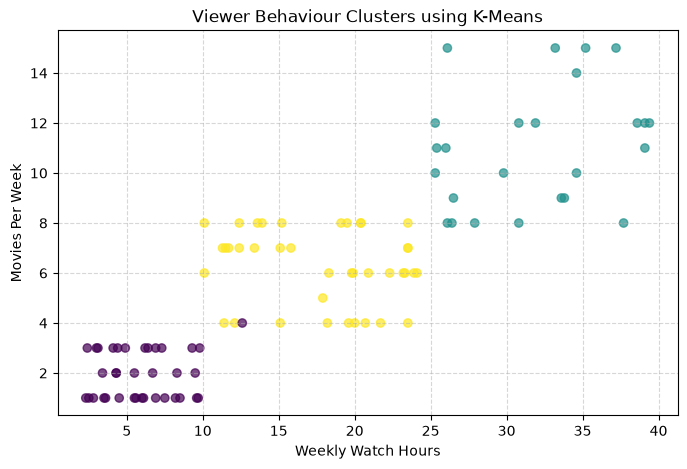

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Environment ready!")

# Load dataset
df = pd.read_csv("viewer_behaviour_dataset.csv")
df.columns = df.columns.str.strip()

print("\n--- Available Columns ---")
print(df.columns.tolist())
print("-------------------------")

print("\n--- First 10 Rows ---")
print(df.head(10))

print("\n--- Dataset Information ---")
print(df.info())

print("\n--- Statistical Summary ---")
print(df.describe())

# --------------------------------------------------
# STEP 1: Select Features
# --------------------------------------------------

X = df[[
    "Weekly_Watch_Hours",
    "Movies_Per_Week",
    "Avg_Rating_Given",
    "Weekend_Watch_Hours"
]]

print("\n--- Selected Features ---")
print(X.head())

print("\nX shape:", X.shape)

# --------------------------------------------------
# STEP 2: Standardize the Data
# --------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nData standardized successfully!")

# --------------------------------------------------
# STEP 3: Apply K-Means Clustering
# --------------------------------------------------

model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

model.fit(X_scaled)

print("\nK-Means clustering completed successfully!")

# Add cluster number to dataset
df["Cluster"] = model.labels_

# --------------------------------------------------
# STEP 4: Display Clustered Data
# --------------------------------------------------

print("\n--- Viewer Data with Cluster ---")
print(df.head(20))

# --------------------------------------------------
# STEP 5: Count Viewers in Each Cluster
# --------------------------------------------------

print("\n--- Number of Viewers in Each Cluster ---")
print(df["Cluster"].value_counts().sort_index())

# --------------------------------------------------
# STEP 6: Find Cluster Centers
# --------------------------------------------------

cluster_centers = scaler.inverse_transform(
    model.cluster_centers_
)

centers = pd.DataFrame(
    cluster_centers,
    columns=[
        "Weekly_Watch_Hours",
        "Movies_Per_Week",
        "Avg_Rating_Given",
        "Weekend_Watch_Hours"
    ]
)

print("\n--- Cluster Centers ---")
print(centers.round(2))

# --------------------------------------------------
# STEP 7: Visualization
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Weekly_Watch_Hours"],
    df["Movies_Per_Week"],
    c=df["Cluster"],
    alpha=0.7
)

plt.xlabel("Weekly Watch Hours")
plt.ylabel("Movies Per Week")
plt.title("Viewer Behaviour Clusters using K-Means")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()